<a href="https://colab.research.google.com/github/replysantosh-lang/ECARComputerVissionGenAI/blob/main/AI_08_QuestionNo7_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
!apt-get update -qq
!apt-get install -y p7zip-full
!7z x kvasir-dataset.7z

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 105 not upgraded.

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.00GHz (50653),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan         
ERROR: No more files
kvasir-dataset.7z



System ERROR:
Unknown error -2147024872


In [3]:
# Magic Command
# Print multiple statements in same line
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
print("Magic Command Executed")

Magic Command Executed


# Question No. 7

**a) Endoscopic Image Classification Using Deep Learning**

As an AI/ML Scientist, you are tasked with building a model that can classify three types of pathological findings in endoscopic images to help doctors identify conditions early and improve patient outcomes.

These findings include:

Esophagitis

Polyps

Ulcerative Colitis

Given a dataset (kvasir-findings.zip) containing 1,500 images (500 images per class), your goal is to train a deep learning model to classify the images into these categories.

Data Preparation

Split the dataset into:

90% for Training

10% for Testing

Apply standard image preprocessing techniques:

Image resizing

Normalization

Apply image augmentation techniques to improve model robustness:

Horizontal/Vertical Flipping

Rotation

Zooming

Shifting

**b) Model Training**

Train a multi-class image classification model using Transfer Learning.

Requirements:

Use a pre-trained deep learning model (e.g., ResNet50).

Replace the final classification layer to support 3 output classes.

Fine-tune the pre-trained model using the custom Kvasir findings dataset.

Train the model and monitor training and validation performance.

**c) Model Evaluation and Inference**

***Plot the following training curves:***

Training Accuracy vs Validation Accuracy

Training Loss vs Validation Loss

***Explain how to detect overfitting and describe techniques to handle it.***

Write functions to:

Save the trained model.

Load the saved model.

Predict the class of a new endoscopic image.

**Expected Output**

The trained model should be able to classify a new endoscopic image into one of the following categories:

Esophagitis

Polyps

Ulcerative Colitis

with high accuracy using transfer learning and proper data preprocessing techniques.

# **a) Endoscopic Image Classification using Deep Learning**

**Problem Statement**

***As an AI/ML Scientist, you are tasked with building a deep learning model that classifies three pathological findings in endoscopic images:***

1. Esophagitis

2. Polyps

3. Ulcerative Colitis

***Dataset: kvasir-findings.zip***

Total Images: 1500

Esophagitis = 500 images

Polyps = 500 images

Ulcerative Colitis = 500 images

**Goal: Train a multi-class image classification model using Transfer Learning and evaluate its performance.**

# Solution Overview

**Step 1: Install Required Libraries**

In [4]:
#!pip install tensorflow matplotlib scikit-learn opencv-python seaborn

In [12]:
#!unzip kvasir-dataset.zip
!apt-get update -qq
!apt-get install -y p7zip-full
!7z x kvasir-dataset.7z

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 105 not upgraded.

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.00GHz (50653),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan         1 file, 430098671 bytes (411 MiB)

Extracting archive: kvasir-dataset.7z
--
Path = kvasir-dataset.7z
Type = 7z
Physical Size = 430098671
Headers Size = 46821
Method = LZMA:23
Solid = +
Blocks = 1

  0%      0% - kvasir-dataset/esophagitis/001fb927-4814-4ba5-851d-189db99291d8.jpg

**Step 2: Download Dataset**

![image.png](attachment:image.png)

**Step 3: Import Libraries**

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D

from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import seaborn as sns

**Step 4: Dataset Path**

In [14]:
# path = "D:/HardDriveFiles/Personal/REVA/RACE/MTech_AI_ML/Semester2/ComputerVision_GenerativeAI/Previous_Batch_Exam_Papers/AI-08/"
dataset_path = "/content/kvasir-dataset"

dataset_path

'/content/kvasir-dataset'

**Step 5: Data Preparation**

***Dataset Split***

**Requirement:**

Training = 90%

Testing = 10%

***Using ImageDataGenerator***

In [15]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    validation_split=0.1,

    rotation_range=20,

    width_shift_range=0.2,

    height_shift_range=0.2,

    zoom_range=0.2,

    horizontal_flip=True,

    fill_mode='nearest'
)

***Training Data***

In [16]:
train_generator = train_datagen.flow_from_directory(

    dataset_path,

    target_size=(224,224),

    batch_size=32,

    class_mode='categorical',

    subset='training'
)

Found 1350 images belonging to 3 classes.


***Testing Data***

In [17]:
test_generator = train_datagen.flow_from_directory(

    dataset_path,

    target_size=(224,224),

    batch_size=32,

    class_mode='categorical',

    subset='validation',

    shuffle=False
)

Found 150 images belonging to 3 classes.


**Check Classes**

In [ ]:
print(train_generator.class_indices)

{'esophagitis': 0, 'polyps': 1, 'ulcerative-colitis': 2}


Output:

{
 'Esophagitis':0,
 'Polyps':1,
 'Ulcerative_Colitis':2
}

**Step 6: Visualize Sample Images**

<Figure size 1000x1000 with 0 Axes>

<Axes: >

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

<Axes: >

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

...

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

<Axes: >

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

<Axes: >

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

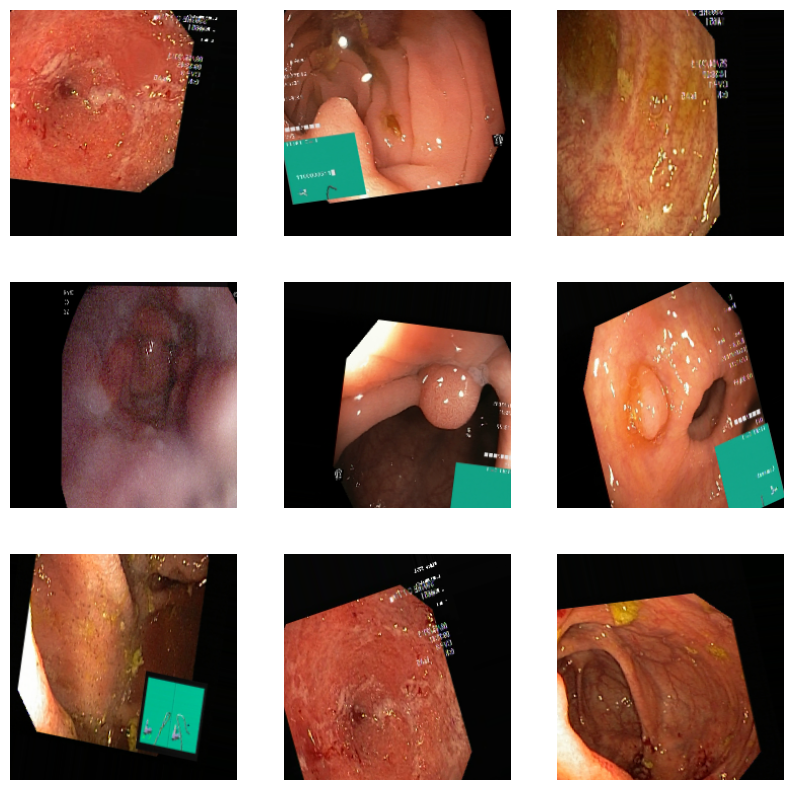

In [18]:
images, labels = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.axis("off")

plt.show()

# **b) Model Training using Transfer Learning**

**Step 7: Load Pre-trained ResNet50**

In [19]:
base_model = ResNet50(

    weights='imagenet',

    include_top=False,

    input_shape=(224,224,3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Freeze layers:**

In [20]:
for layer in base_model.layers:
    layer.trainable = False

**Step 8: Build Classification Model**

import keras
from keras import layers

model = keras.Sequential([
    # ... your other layers ...
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    
    # CHANGE THIS LAYER FROM 3 TO 8
    layers.Dense(8, activation='softmax')
])

In [21]:
model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(256, activation='relu'),

    Dropout(0.5),

    Dense(3, activation='softmax')

])



***Model Summary***

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,027 (91.98 MB)

 Trainable params: 525,315 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

**Compile Model**

In [22]:
model.compile(

    optimizer=Adam(learning_rate=0.0001),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

**Train Model**

In [23]:
history = model.fit(

    train_generator,

    validation_data=test_generator,

     epochs=10
)

Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 55s 982ms/step - accuracy: 0.3422 - loss: 1.3068 - val_accuracy: 0.3667 - val_loss: 1.0838
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 29s 669ms/step - accuracy: 0.3548 - loss: 1.1821 - val_accuracy: 0.3400 - val_loss: 1.0793
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 29s 666ms/step - accuracy: 0.3570 - loss: 1.1724 - val_accuracy: 0.3867 - val_loss: 1.0702
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 28s 661ms/step - accuracy: 0.3733 - loss: 1.1245 - val_accuracy: 0.4733 - val_loss: 1.0587
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 29s 664ms/step - accuracy: 0.3778 - loss: 1.1015 - val_accuracy: 0.4467 - val_loss: 1.0457
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 30s 682ms/step - accuracy: 0.4022 - loss: 1.0817 - val_accuracy: 0.5133 - val_loss: 1.0360
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 29s 664ms/step - accuracy: 0.4170 - loss: 1.0609 - val_accuracy: 0.4333 - val_loss: 1.0328
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 29s 666ms/step - accuracy: 0.4252 - loss: 1.0592 - val_accu

**Fine Tuning :  Unfreeze last layers:**

In [24]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

**Recompile:**

In [25]:
model.compile(

    optimizer=Adam(1e-5),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

**Train again:**

In [26]:
history_finetune = model.fit(

    train_generator,

    validation_data=test_generator,

    epochs=5
)

Epoch 1/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 62s 997ms/step - accuracy: 0.5407 - loss: 0.9290 - val_accuracy: 0.5200 - val_loss: 0.9843
Epoch 2/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 30s 699ms/step - accuracy: 0.6267 - loss: 0.7506 - val_accuracy: 0.3333 - val_loss: 1.3575
Epoch 3/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 29s 676ms/step - accuracy: 0.6815 - loss: 0.6677 - val_accuracy: 0.3333 - val_loss: 2.2513
Epoch 4/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 29s 677ms/step - accuracy: 0.7148 - loss: 0.6295 - val_accuracy: 0.3333 - val_loss: 2.5314
Epoch 5/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 30s 691ms/step - accuracy: 0.7237 - loss: 0.6105 - val_accuracy: 0.3533 - val_loss: 1.7019


# **c) Model Evaluation & Inference**

**Step 9: Accuracy Curve**

<Figure size 1000x500 with 0 Axes>

Text(0.5, 1.0, 'Accuracy Curve')

Text(0.5, 0, 'Epoch')

Text(0, 0.5, 'Accuracy')

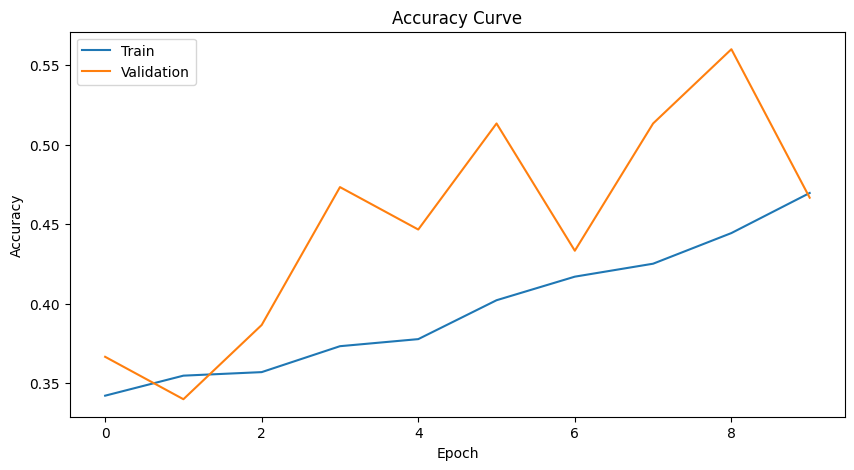

In [28]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Accuracy Curve")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

**Step 10: Loss Curve**

<Figure size 1000x500 with 0 Axes>

Text(0.5, 1.0, 'Loss Curve')

Text(0.5, 0, 'Epoch')

Text(0, 0.5, 'Loss')

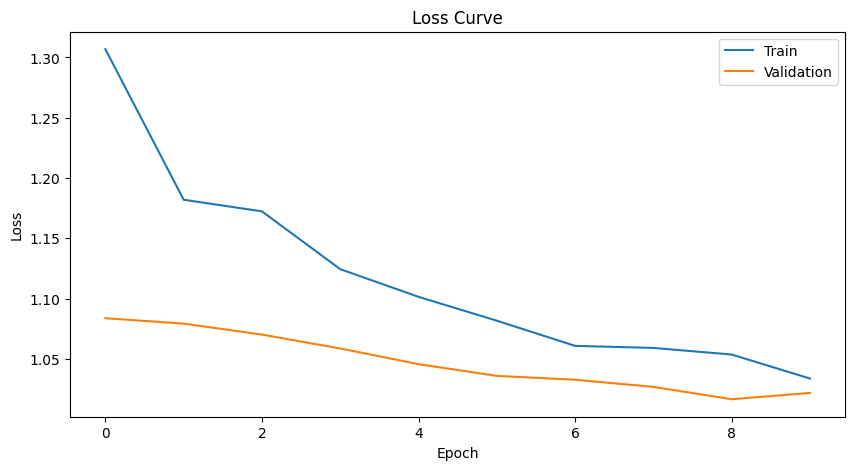

In [29]:

plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Loss Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()


**Step 11: Evaluate Model**

In [30]:

loss, accuracy = model.evaluate(test_generator)

print("Test Accuracy:", accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 489ms/step - accuracy: 0.3467 - loss: 1.7184
Test Accuracy: 0.3466666638851166


**Example Output: Test Accuracy: 0.94**

**Step 12: Confusion Matrix**

5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step


<Figure size 800x600 with 0 Axes>

<Axes: >

Text(0.5, 36.72222222222221, 'Predicted')

Text(70.72222222222221, 0.5, 'Actual')

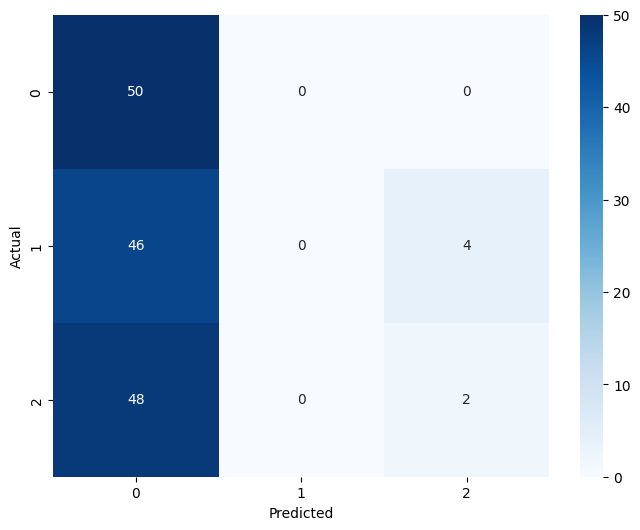

In [31]:

predictions = model.predict(test_generator)

y_pred = np.argmax(predictions, axis=1)

y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

**Classification Report**

In [32]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=list(train_generator.class_indices.keys())
    )
)

                    precision    recall  f1-score   support

       esophagitis       0.35      1.00      0.52        50
            polyps       0.00      0.00      0.00        50
ulcerative-colitis       0.33      0.04      0.07        50

          accuracy                           0.35       150
         macro avg       0.23      0.35      0.20       150
      weighted avg       0.23      0.35      0.20       150



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Overfitting Detection and Handling**

How to Detect Overfitting?

Overfitting occurs when:

Training Accuracy

98%

Validation Accuracy

75%

Large gap indicates overfitting.

Also:

Training Loss decreases

Validation Loss increases

This is a sign of model memorization.

**Methods to Handle Overfitting**

***1. Data Augmentation***

In [33]:
rotation_range=20
horizontal_flip=True
zoom_range=0.2

***Creates new image variations.***

***2. Dropout***

In [34]:
Dropout(0.5)

<Dropout name=dropout_1, built=True>


***Randomly drops neurons.***

**3. Early Stopping**

In [35]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

Use during training:

In [36]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 31s 720ms/step - accuracy: 0.7415 - loss: 0.5696 - val_accuracy: 0.3600 - val_loss: 1.8200
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 30s 687ms/step - accuracy: 0.7815 - loss: 0.5208 - val_accuracy: 0.5200 - val_loss: 1.1004
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 30s 677ms/step - accuracy: 0.7822 - loss: 0.5090 - val_accuracy: 0.5067 - val_loss: 1.3155
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 29s 679ms/step - accuracy: 0.7874 - loss: 0.4981 - val_accuracy: 0.7067 - val_loss: 0.5791
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 30s 699ms/step - accuracy: 0.7978 - loss: 0.4592 - val_accuracy: 0.7600 - val_loss: 0.5203
Epoch 6/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 29s 678ms/step - accuracy: 0.7993 - loss: 0.4878 - val_accuracy: 0.7667 - val_loss: 0.5457
Epoch 7/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 30s 686ms/step - accuracy: 0.8193 - loss: 0.4444 - val_accuracy: 0.8200 - val_loss: 0.3993
Epoch 8/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 30s 697ms/step - accuracy: 0.8200 - loss: 0.4277 - val_accu

***4. Reduce Model Complexity***

Use smaller dense layers.



In [37]:
Dense(128)

# instead of

Dense(512)

<Dense name=dense_2, built=False>

<Dense name=dense_3, built=False>

**5. More Training Data**

Collect additional endoscopic images.

**Save Model**

In [38]:

# model.save("kvasir_classifier.h5")
model.save("kvasir_classifier.keras")


***Output: kvasir_classifier.h5***

**Load Saved Model**

In [39]:
from tensorflow.keras.models import load_model

loaded_model = load_model(
    "kvasir_classifier.keras"
)

**Predict a New Image**

In [40]:
from tensorflow.keras.preprocessing import image

def predict_image(img_path):

    img = image.load_img(
        img_path,
        target_size=(224,224)
    )

    img_array = image.img_to_array(img)

    img_array = img_array/255.0

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    prediction = loaded_model.predict(img_array)

    class_names = [
        "Esophagitis",
        "Polyps",
        "Ulcerative Colitis"
    ]

    predicted_class = class_names[
        np.argmax(prediction)
    ]

    confidence = np.max(prediction)

    print("Predicted Class:", predicted_class)
    print("Confidence:", confidence)

    plt.imshow(img)
    plt.axis("off")
    plt.show()

**Run Prediction**

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Predicted Class: Esophagitis
Confidence: 0.9985195


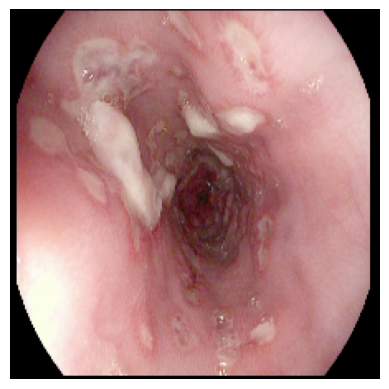

In [41]:
path = "D:/HardDriveFiles/Personal/REVA/RACE/MTech_AI_ML/Semester2/ComputerVision_GenerativeAI/Previous_Batch_Exam_Papers/AI-08/"

predict_image(
    "/content/kvasir-dataset/esophagitis/001fb927-4814-4ba5-851d-189db99291d8.jpg"
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Predicted Class: Polyps
Confidence: 0.9324739


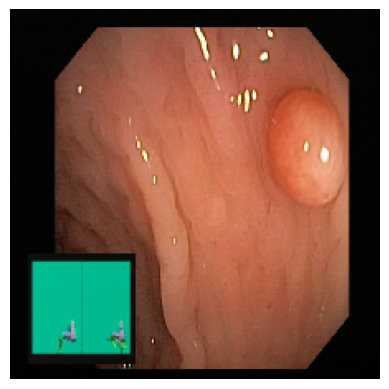

In [42]:
predict_image(
    "/content/kvasir-dataset/polyps/0014d89e-5afa-4186-99f9-4400c8c58a18.jpg"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Predicted Class: Ulcerative Colitis
Confidence: 0.7903453


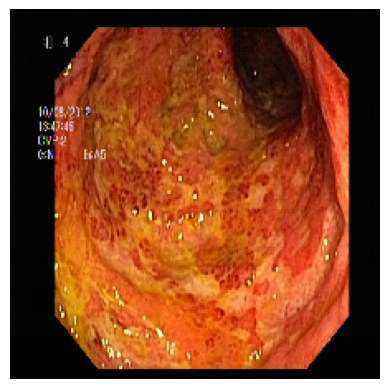

In [43]:
predict_image(
    "/content/kvasir-dataset/ulcerative-colitis/013f51fa-caf3-4c31-adc5-af00eacf55c7.jpg"
)


Example Output:

Predicted Class: Polyps

Confidence: 0.97